In [1]:
import sqlite3 as sql
import pandas as pd

In [2]:
#connection

conn = sql.connect('database.sqlite')
conn

In [3]:
a = conn.execute('select * from Salaries')
a

In [4]:
pd.read_sql_query('select * from sqlite_master',conn)

,type,name,tbl_name,rootpage,sql
0,table,Salaries,Salaries,2,CREATE TABLE Salaries (\n Id INTEGER PRIMAR...
1,index,salaries_year_idx,Salaries,16566,CREATE INDEX salaries_year_idx ON Salaries (Year)


In [5]:
pd.read_sql_query('select * from Salaries',conn)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0,400184.25,,567595.43,567595.43,2011,,San Francisco,
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,,538909.28,538909.28,2011,,San Francisco,
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,,335279.91,335279.91,2011,,San Francisco,
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916,56120.71,198306.9,,332343.61,332343.61,2011,,San Francisco,
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737,182234.59,,326373.19,326373.19,2011,,San Francisco,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148649,148650,Roy I Tillery,Custodian,0,0,0,0,0.00,0.00,2014,,San Francisco,PT
148650,148651,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148651,148652,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148652,148653,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,


In [6]:
pd.read_sql_query('select * from Salaries where EmployeeName is Null', conn)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status


In [7]:
pd.read_sql_query('select EmployeeName, JobTitle from Salaries where JobTitle is null', conn)

,EmployeeName,JobTitle


In [8]:
pd.read_sql_query('select EmployeeName, JobTitle from Salaries where EmployeeName is null', conn)

,EmployeeName,JobTitle


In [10]:
pd.read_sql_query('select EmployeeName, JobTitle from Salaries where JobTitle = "Not provided"', conn)

,EmployeeName,JobTitle
0,Not provided,Not provided
1,Not provided,Not provided
2,Not provided,Not provided
3,Not provided,Not provided


In [11]:
#without null records

pd.read_sql_query('select EmployeeName, JobTitle, BasePay from Salaries where BasePay is not null', conn)

,EmployeeName,JobTitle,BasePay
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6
...,...,...,...
148649,Roy I Tillery,Custodian,0
148650,Not provided,Not provided,Not Provided
148651,Not provided,Not provided,Not Provided
148652,Not provided,Not provided,Not Provided


In [12]:
# function
def sql_query(q):
    return pd.read_sql_query(q,conn)

In [13]:
q = '''
select * from Salaries'''
sql_query(q)

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0,400184.25,,567595.43,567595.43,2011,,San Francisco,
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,,538909.28,538909.28,2011,,San Francisco,
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,,335279.91,335279.91,2011,,San Francisco,
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916,56120.71,198306.9,,332343.61,332343.61,2011,,San Francisco,
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737,182234.59,,326373.19,326373.19,2011,,San Francisco,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148649,148650,Roy I Tillery,Custodian,0,0,0,0,0.00,0.00,2014,,San Francisco,PT
148650,148651,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148651,148652,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,
148652,148653,Not provided,Not provided,Not Provided,Not Provided,Not Provided,Not Provided,0.00,0.00,2014,,San Francisco,


In [14]:
# distinct

q = '''select distinct JobTitle from Salaries'''
sql_query(q)

,JobTitle
0,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY
1,CAPTAIN III (POLICE DEPARTMENT)
2,WIRE ROPE CABLE MAINTENANCE MECHANIC
3,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)"
4,ASSISTANT DEPUTY CHIEF II
...,...
2154,"Sr Cnselor, Juv Hall (SFERS)"
2155,Forensic Toxicologist Supervis
2156,Conversion
2157,Cashier 3


In [15]:
#not provide
q = '''select distinct JobTitle from Salaries where JobTitle != "Not provided" '''
sql_query(q)

,JobTitle
0,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY
1,CAPTAIN III (POLICE DEPARTMENT)
2,WIRE ROPE CABLE MAINTENANCE MECHANIC
3,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)"
4,ASSISTANT DEPUTY CHIEF II
...,...
2153,Marina Associate Manager
2154,"Sr Cnselor, Juv Hall (SFERS)"
2155,Forensic Toxicologist Supervis
2156,Conversion


In [16]:
# year
q = '''select distinct year from Salaries'''
sql_query(q)

,Year
0,2011
1,2012
2,2013
3,2014


In [17]:
# Alias (Renaming )
q = '''select employeename Employee from Salaries'''
sql_query(q)

,Employee
0,NATHANIEL FORD
1,GARY JIMENEZ
2,ALBERT PARDINI
3,CHRISTOPHER CHONG
4,PATRICK GARDNER
...,...
148649,Roy I Tillery
148650,Not provided
148651,Not provided
148652,Not provided


In [18]:
q = '''select employeename "Employee Name" from Salaries'''
sql_query(q)

,Employee Name
0,NATHANIEL FORD
1,GARY JIMENEZ
2,ALBERT PARDINI
3,CHRISTOPHER CHONG
4,PATRICK GARDNER
...,...
148649,Roy I Tillery
148650,Not provided
148651,Not provided
148652,Not provided


In [23]:
# short names nick names set

q = '''select employeename  "Employee" , JobTitle Title from Salaries'''
sql_query(q)

,Employee,Title
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT)
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT)
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)"
...,...,...
148649,Roy I Tillery,Custodian
148650,Not provided,Not provided
148651,Not provided,Not provided
148652,Not provided,Not provided


In [24]:
q = '''select employeename as "(Employee)", JobTitle Title from Salaries'''
sql_query(q)

,(Employee),Title
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT)
2,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT)
3,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC
4,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)"
...,...,...
148649,Roy I Tillery,Custodian
148650,Not provided,Not provided
148651,Not provided,Not provided
148652,Not provided,Not provided


In [25]:
#Acending/Decending

q = '''select BasePay, OvertimePay, OtherPay from Salaries order by 1'''
sql_query(q)

,BasePay,OvertimePay,OtherPay
0,-166.01,249.02,0
1,-121.63,182.7,0
2,-109.22,163.83,0
3,-106.6,159.9,0
4,-101.88,153.08,0
...,...,...,...
148649,,0,0
148650,Not Provided,Not Provided,Not Provided
148651,Not Provided,Not Provided,Not Provided
148652,Not Provided,Not Provided,Not Provided


In [26]:
q = '''select BasePay, OvertimePay, OtherPay from Salaries order by 1 desc'''
sql_query(q)

,BasePay,OvertimePay,OtherPay
0,Not Provided,Not Provided,Not Provided
1,Not Provided,Not Provided,Not Provided
2,Not Provided,Not Provided,Not Provided
3,Not Provided,Not Provided,Not Provided
4,,0,149934.11
...,...,...,...
148649,-101.88,153.08,0
148650,-106.6,159.9,0
148651,-109.22,163.83,0
148652,-121.63,182.7,0


In [31]:
#Top 10 
q = '''select JobTitle , basepay, otherpay, Overtimepay, totalpay from Salaries order by 2 desc limit 10'''
sql_query(q)

,JobTitle,BasePay,OtherPay,OvertimePay,TotalPay
0,Not provided,Not Provided,Not Provided,Not Provided,0.00
1,Not provided,Not Provided,Not Provided,Not Provided,0.00
2,Not provided,Not Provided,Not Provided,Not Provided,0.00
3,Not provided,Not Provided,Not Provided,Not Provided,0.00
4,Deputy Chief 3,,149934.11,0,149934.11
5,Licensed Vocational Nurse,,110485.41,0,110485.41
6,Park Patrol Officer,,120000,0,120000.00
7,Police Officer 3,,106079.31,0,106079.31
8,Deputy Sheriff,,81299.02,0,81299.02
9,Executive Contract Employee,,105105,0,105105.00


<Axes: xlabel='JobTitle'>

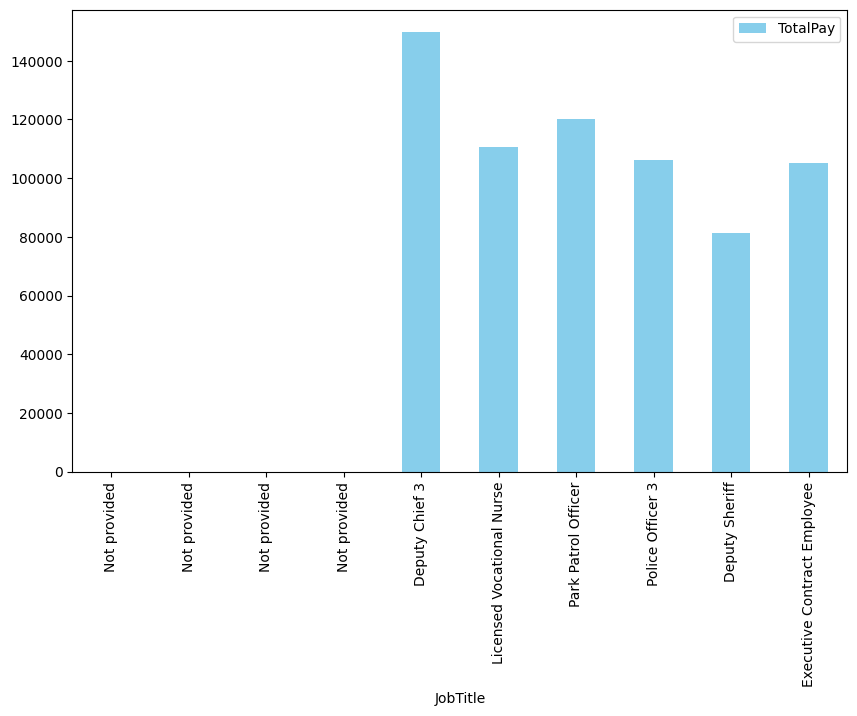

In [33]:
a = pd.read_sql_query(q,conn)
a.plot(kind = 'bar' , x = 'JobTitle' , y = 'TotalPay', color = 'skyblue', figsize = (10,6))

In [36]:
#operators

# show jobtitle where overtime > 50k and excluded 'not provided' rows 

q = '''select JobTitle, Overtimepay from Salaries where Overtimepay > 5000 and JobTitle != "Not provided"'''
sql_query(q)

,JobTitle,OvertimePay
0,CAPTAIN III (POLICE DEPARTMENT),245131.88
1,CAPTAIN III (POLICE DEPARTMENT),106088.18
2,WIRE ROPE CABLE MAINTENANCE MECHANIC,56120.71
3,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",9737.00
4,ASSISTANT DEPUTY CHIEF II,8601.00
...,...,...
35824,Nurse Practitioner,7230.79
35825,Nurse Practitioner,5207.56
35826,Nursing Supervisor,6190.27
35827,Cook,6879.59


In [37]:
#show all employeename , totalpay with a totalpay b/w 50000 and 7000

q = ''' select employeename, totalpay from Salaries where totalpay between 50000 and 75000'''
sql_query(q)

,EmployeeName,TotalPay
0,MAMIKO NAKAMURA,74999.62
1,HEDLEY PRINCE,74998.73
2,LINDA BARNARD,74998.30
3,ANGELA WHITTAKER,74997.84
4,JANE CHU,74997.81
...,...,...
33552,Stephanie Reidy,51785.23
33553,Maria Theresa Luna,52266.82
33554,Paul E Maltzer,51673.98
33555,Kevin I Dolar,50953.19


2. Find which year has missing data of Employees with 'Not Provided'/ 'Not provided' .

3. Number of unique agencies

4. Show Average BasePay, OvertimePay, and TotalPay for year 2011

5. Plot the top 10 job titles with the highest TotalPay in 2014.

6. Which job titles have overtime pay exceeding $150,000 exluding 'Not provided'

7. Find all employees whose job titles contain the word “CHIEF”

8. Count how many employees have job titles containing “ENGINEER” and “Fire” in year 2012 and 2013

9. Distinct job titles starting with "CAPTAIN"

10. Employees having basepay > 50k and totalpay < 150000 exlucding 'Not Provided'